# CORD EDA

Initial reality-check notebook for the CORD dataset.

Goals:
- verify loader assumptions
- inspect raw record structure
- summarize image / token / bbox / field stats
- identify consistency opportunities for later risk features


In [29]:
# imports + setup
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from datasets import load_from_disk

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.data_utils import load_cord_split, preview_record
from utils.eda_utils import (
    print_basic_dataset_summary,
    summarize_field_presence,
    field_frequency_table,
    missingness_table,
    summarize_image_sizes,
    summarize_token_box_counts,
    plot_histogram
)

DATA_ROOT = PROJECT_ROOT / 'data'
CORD_ROOT = DATA_ROOT / 'CORD'
CORD_ROOT


PosixPath('/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/data/CORD')

In [2]:
CORD_ROOT = Path("/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/CORD")
train_ds = load_from_disk(str(CORD_ROOT / "train"))

type(train_ds), len(train_ds)

(datasets.arrow_dataset.Dataset, 800)

In [3]:
train_ds

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 800
})

In [4]:
train_ds.features


{'image': Image(mode=None, decode=True), 'ground_truth': Value('string')}

In [5]:
example = train_ds[0]
example.keys()

dict_keys(['image', 'ground_truth'])

In [6]:
for k, v in example.items():
    print("=" * 80)
    print(k)
    print(type(v))
    if isinstance(v, dict):
        print("dict keys:", list(v.keys())[:20])
    elif isinstance(v, list):
        print("list length:", len(v))
        if len(v) > 0:
            print("first element type:", type(v[0]))
            print("first element preview:", v[0])
    else:
        print(v)


image
<class 'PIL.PngImagePlugin.PngImageFile'>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=864x1296 at 0x13F249E80>
ground_truth
<class 'str'>
{"gt_parse": {"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1 x", "price": "70,000"}, {"nm": "Free Ice Tea", "cnt": "3 x", "price": "0"}, {"nm": "Organic Green Sa", "cnt": "1 x", "price": "65,000"}, {"nm": "Ice Tea", "cnt": "1 x", "price": "18,000"}, {"nm": "Ice Orange", "cnt": "1 x", "price": "29,000"}, {"nm": "Ayam Suir Bali", "cnt": "1 x", "price": "85,000"}, {"nm": "Tahu Goreng", "cnt": "2 x", "price": "36,000"}, {"nm": "Tempe Goreng", "cnt": "2 x", "price": "36,000"}, {"nm": "Tahu Telor Asin", "cnt": "1 x", "price": "40,000."}, {"nm": "Nasi Goreng Samb", "cnt": "1 x", "price": "70,000"}, {"nm": "

In [7]:
example

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=864x1296>,
 'ground_truth': '{"gt_parse": {"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1 x", "price": "70,000"}, {"nm": "Free Ice Tea", "cnt": "3 x", "price": "0"}, {"nm": "Organic Green Sa", "cnt": "1 x", "price": "65,000"}, {"nm": "Ice Tea", "cnt": "1 x", "price": "18,000"}, {"nm": "Ice Orange", "cnt": "1 x", "price": "29,000"}, {"nm": "Ayam Suir Bali", "cnt": "1 x", "price": "85,000"}, {"nm": "Tahu Goreng", "cnt": "2 x", "price": "36,000"}, {"nm": "Tempe Goreng", "cnt": "2 x", "price": "36,000"}, {"nm": "Tahu Telor Asin", "cnt": "1 x", "price": "40,000."}, {"nm": "Nasi Goreng Samb", "cnt": "1 x", "price": "70,000"}, {"nm": "Bbk Panggang Sam", "cnt": "3 x", "price": "366,000"}, {"nm": 

In [8]:
# load a small sample first to verify assumptions
sample_records = load_cord_split('train', data_root=DATA_ROOT)
sample_records = sample_records[:10]
len(sample_records)


10

In [9]:
# inspect one record in compact form
record = sample_records[0]
preview_record(record)

doc_id: cord_train_0
dataset: CORD
split: train
image_path: None
image object present: True
image_size: {'width': 864, 'height': 1296}
num_tokens: 135
num_boxes: 135
num_fields: 7
field keys: ['menu', 'menu_count', 'sub_total.subtotal_price', 'sub_total.service_price', 'sub_total.tax_price', 'sub_total.etc', 'total.total_price']
metadata keys: ['version', 'split', 'image_id', 'image_size']


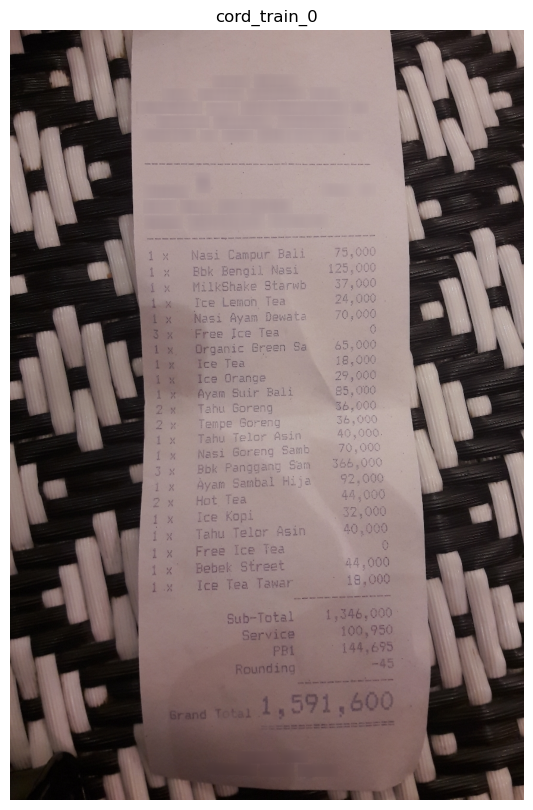

In [10]:
# visualize one example image
img = record.image if record.image is not None else Image.open(record.image_path)
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis('off')
plt.title(record.doc_id)
plt.show()


In [11]:
# load a larger set for summary statistics
records = load_cord_split('train', data_root=DATA_ROOT)
print_basic_dataset_summary(records)


Documents: 800
Datasets: {'CORD': 800}
Splits: {'train': 800}

Token/box summary:
         n_tokens     n_boxes
count  800.000000  800.000000
mean    24.208750   24.208750
std     15.651402   15.651402
min      5.000000    5.000000
25%     15.000000   15.000000
50%     20.000000   20.000000
75%     28.000000   28.000000
max    135.000000  135.000000


In [12]:
# field presence summary
presence = summarize_field_presence(records)
presence.head(20)


,doc_id,dataset,split,n_fields,has_menu,has_menu_count,has_sub_total.subtotal_price,has_sub_total.service_price,has_sub_total.tax_price,has_sub_total.etc,has_total.total_price,has_total.cashprice,has_total.changeprice,has_total.menutype_cnt,has_total.menuqty_cnt,has_sub_total.discount_price,has_total.total_etc,has_total.creditcardprice,has_total.emoneyprice,has_sub_total.othersvc_price
0,cord_train_0,CORD,train,7,1,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,cord_train_1,CORD,train,6,1,1,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cord_train_2,CORD,train,8,1,1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,cord_train_3,CORD,train,7,1,1,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,cord_train_4,CORD,train,7,1,1,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,cord_train_5,CORD,train,8,1,1,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6,cord_train_6,CORD,train,7,1,1,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,cord_train_7,CORD,train,8,1,1,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,cord_train_8,CORD,train,5,1,1,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,cord_train_9,CORD,train,6,1,1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
freq_df = field_frequency_table(records)
miss_df = missingness_table(presence)

display(freq_df.head(30))
display(miss_df.head(30))

,field,doc_count,doc_fraction
0,menu,800,1.00000
1,menu_count,800,1.00000
2,total.total_price,779,0.97375
3,sub_total.subtotal_price,529,0.66125
4,total.cashprice,517,0.64625
5,total.changeprice,500,0.62500
6,sub_total.tax_price,354,0.44250
7,total.menuqty_cnt,228,0.28500
8,total.creditcardprice,121,0.15125
9,sub_total.service_price,98,0.12250


,field,present_docs,missing_docs,missing_fraction
0,sub_total.othersvc_price,1,799,0.99875
1,total.total_etc,26,774,0.96750
2,total.menutype_cnt,42,758,0.94750
3,total.emoneyprice,46,754,0.94250
4,sub_total.discount_price,61,739,0.92375
5,sub_total.etc,68,732,0.91500
6,sub_total.service_price,98,702,0.87750
7,total.creditcardprice,121,679,0.84875
8,total.menuqty_cnt,228,572,0.71500
9,sub_total.tax_price,354,446,0.55750


In [30]:
# quick reduced-schema probe
candidate_terms = ['store', 'vendor', 'date', 'subtotal', 'tax', 'total', 'menu', 'item', 'price']
freq_df[freq_df['field'].str.lower().apply(lambda x: any(term in x for term in candidate_terms))]


,field,doc_count,doc_fraction
0,menu,800,1.00000
1,menu_count,800,1.00000
2,total.total_price,779,0.97375
3,sub_total.subtotal_price,529,0.66125
4,total.cashprice,517,0.64625
5,total.changeprice,500,0.62500
6,sub_total.tax_price,354,0.44250
7,total.menuqty_cnt,228,0.28500
8,total.creditcardprice,121,0.15125
9,sub_total.service_price,98,0.12250


In [31]:
# summarize image dimensions and aspect ratios for CORD receipts
img_df = summarize_image_sizes(records)
display(img_df.head())
img_df[["width", "height", "aspect_ratio"]].describe()

,doc_id,dataset,split,width,height,aspect_ratio
0,cord_train_0,CORD,train,864,1296,0.666667
1,cord_train_1,CORD,train,864,1296,0.666667
2,cord_train_2,CORD,train,720,1280,0.562500
3,cord_train_3,CORD,train,1108,1478,0.749662
4,cord_train_4,CORD,train,864,1296,0.666667


,width,height,aspect_ratio
count,800.000000,800.000000,800.000000
mean,997.076250,1573.306250,0.654502
std,544.511981,993.639747,0.066881
min,204.000000,364.000000,0.337895
25%,576.000000,864.000000,0.666667
50%,864.000000,1296.000000,0.666667
75%,1080.000000,1478.000000,0.666667
max,3024.000000,4224.000000,1.000000


,doc_id,dataset,split,n_tokens,n_boxes
0,cord_train_0,CORD,train,135,135
1,cord_train_1,CORD,train,39,39
2,cord_train_2,CORD,train,39,39
3,cord_train_3,CORD,train,22,22
4,cord_train_4,CORD,train,18,18


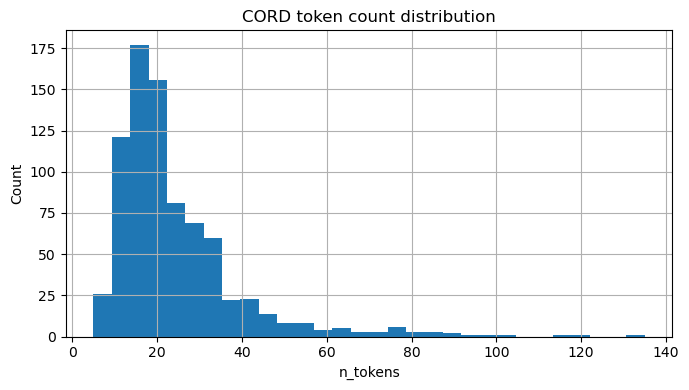

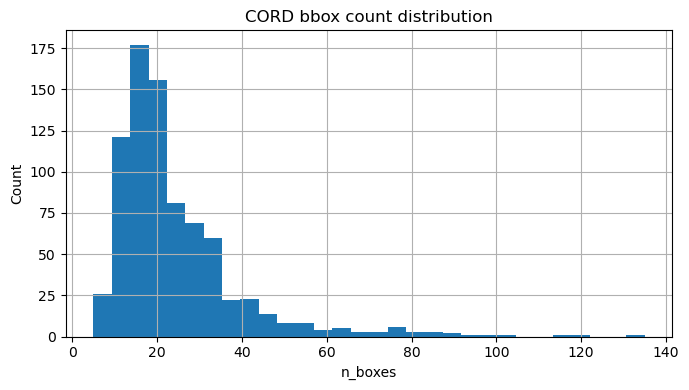

In [32]:
# inspect the distribution of OCR token counts and bounding-box counts
token_df = summarize_token_box_counts(records)
display(token_df.head())
plot_histogram(token_df, "n_tokens", bins=30, title="CORD token count distribution")
plot_histogram(token_df, "n_boxes", bins=30, title="CORD bbox count distribution")

,menu_count_from_list
count,800.000000
mean,2.198750
std,2.880472
min,0.000000
25%,0.000000
50%,2.000000
75%,3.000000
max,22.000000


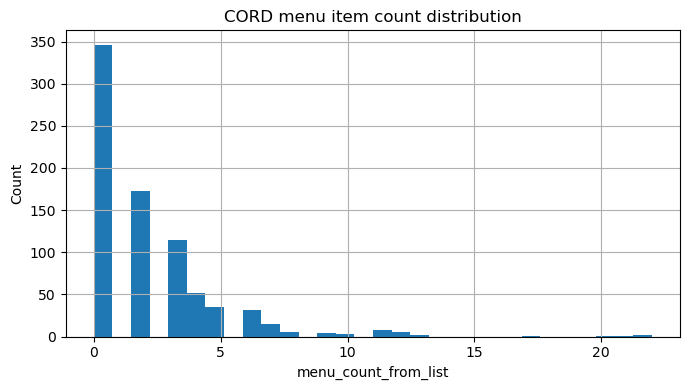

In [33]:
# compute how many menu items appear per receipt to measure structural complexity
menu_counts = []
for r in records:
    menu = r.fields.get("menu", [])
    menu_counts.append(len(menu) if isinstance(menu, list) else 0)

menu_df = pd.DataFrame({"menu_count_from_list": menu_counts})
display(menu_df.describe())
plot_histogram(menu_df, "menu_count_from_list", bins=30, title="CORD menu item count distribution")

In [37]:
# test whether key numeric-looking fields are actually parseable into usable numbers
def parse_amount(x):
    if x is None:
        return None
    s = str(x).strip()
    if s == "":
        return None
    s = s.replace(",", "")
    if s.endswith("."):
        s = s[:-1]
    try:
        return float(s)
    except ValueError:
        return None

amount_fields = [
    "sub_total.subtotal_price",
    "sub_total.service_price",
    "sub_total.tax_price",
    "sub_total.etc",
    "sub_total.discount_price",
    "total.total_price",
    "total.cashprice",
    "total.changeprice",
    "total.creditcardprice",
    "total.emoneyprice",
]

rows = []
for field in amount_fields:
    present = 0
    parseable = 0
    for r in records:
        val = r.fields.get(field)
        if val not in (None, "", [], {}):
            present += 1
            if parse_amount(val) is not None:
                parseable += 1
    rows.append({
        "field": field,
        "present_docs": present,
        "parseable_docs": parseable,
        "parseable_given_present": parseable / present if present else None,
    })

parse_df = pd.DataFrame(rows).sort_values("present_docs", ascending=False)
display(parse_df)

,field,present_docs,parseable_docs,parseable_given_present
5,total.total_price,779,752,0.965340
0,sub_total.subtotal_price,529,506,0.956522
6,total.cashprice,517,480,0.928433
7,total.changeprice,500,477,0.954000
2,sub_total.tax_price,354,333,0.940678
8,total.creditcardprice,121,113,0.933884
1,sub_total.service_price,98,96,0.979592
3,sub_total.etc,68,39,0.573529
4,sub_total.discount_price,61,45,0.737705
9,total.emoneyprice,46,43,0.934783


In [38]:
# measure how often CORD receipts support subtotal/total consistency checks
def safe_sum_menu_prices(menu):
    if not isinstance(menu, list):
        return None
    vals = []
    for item in menu:
        if not isinstance(item, dict):
            continue
        v = parse_amount(item.get("price"))
        if v is None:
            return None
        vals.append(v)
    return sum(vals) if vals else None

rows = []
for r in records:
    fields = r.fields
    menu_sum = safe_sum_menu_prices(fields.get("menu", []))
    subtotal = parse_amount(fields.get("sub_total.subtotal_price"))
    service = parse_amount(fields.get("sub_total.service_price"))
    tax = parse_amount(fields.get("sub_total.tax_price"))
    etc_ = parse_amount(fields.get("sub_total.etc"))
    discount = parse_amount(fields.get("sub_total.discount_price"))
    total = parse_amount(fields.get("total.total_price"))

    rows.append({
        "doc_id": r.doc_id,
        "has_menu_sum": menu_sum is not None,
        "has_subtotal_check": menu_sum is not None and subtotal is not None,
        "has_total_check_basic": subtotal is not None and total is not None,
        "has_total_check_extended": subtotal is not None and total is not None and any(v is not None for v in [service, tax, etc_, discount]),
    })

arith_df = pd.DataFrame(rows)
arith_df.mean(numeric_only=True)

has_menu_sum                0.5475
has_subtotal_check          0.3575
has_total_check_basic       0.6200
has_total_check_extended    0.4200
dtype: float64

In [36]:
# inspect a few receipts with parsed menu sums, subtotals, and totals for sanity checking
examples = []
for r in records[:100]:
    fields = r.fields
    menu_sum = safe_sum_menu_prices(fields.get("menu", []))
    subtotal = parse_amount(fields.get("sub_total.subtotal_price"))
    total = parse_amount(fields.get("total.total_price"))
    if menu_sum is not None or subtotal is not None or total is not None:
        examples.append({
            "doc_id": r.doc_id,
            "menu_sum": menu_sum,
            "subtotal": subtotal,
            "total": total,
        })

display(pd.DataFrame(examples).head(20))

,doc_id,menu_sum,subtotal,total
0,cord_train_0,1346000.0,1346000.000,1591600.0
1,cord_train_1,503000.0,503000.000,580965.0
2,cord_train_2,334000.0,334000.000,334000.0
3,cord_train_3,259000.0,259000.000,302016.0
4,cord_train_4,NaN,43.636,48.0
5,cord_train_5,221000.0,221000.000,261333.0
6,cord_train_6,56181.0,56181.000,61799.0
7,cord_train_7,NaN,33000.000,36300.0
8,cord_train_8,NaN,NaN,36.0
9,cord_train_9,NaN,40.000,40.0


In [39]:
# inspect which key verification-related fields tend to appear together in CORD
co_fields = [
    "sub_total.subtotal_price",
    "sub_total.tax_price",
    "sub_total.service_price",
    "sub_total.discount_price",
    "total.total_price",
    "total.cashprice",
    "total.changeprice",
    "total.creditcardprice",
    "total.emoneyprice",
]

co_rows = []
for r in records:
    row = {"doc_id": r.doc_id}
    for f in co_fields:
        row[f] = int(r.fields.get(f) not in (None, "", [], {}))
    co_rows.append(row)

co_df = pd.DataFrame(co_rows)
display(co_df.head())

co_summary = co_df.drop(columns=["doc_id"]).mean().sort_values(ascending=False)
display(co_summary.to_frame("coverage_fraction"))
display(co_df.drop(columns=["doc_id"]).corr())

,doc_id,sub_total.subtotal_price,sub_total.tax_price,sub_total.service_price,sub_total.discount_price,total.total_price,total.cashprice,total.changeprice,total.creditcardprice,total.emoneyprice
0,cord_train_0,1,1,1,0,1,0,0,0,0
1,cord_train_1,1,1,1,0,1,0,0,0,0
2,cord_train_2,1,0,0,0,1,1,1,0,0
3,cord_train_3,1,1,1,1,1,0,0,0,0
4,cord_train_4,1,1,0,0,1,1,1,0,0


,coverage_fraction
total.total_price,0.97375
sub_total.subtotal_price,0.66125
total.cashprice,0.64625
total.changeprice,0.62500
sub_total.tax_price,0.44250
total.creditcardprice,0.15125
sub_total.service_price,0.12250
sub_total.discount_price,0.07625
total.emoneyprice,0.05750


,sub_total.subtotal_price,sub_total.tax_price,sub_total.service_price,sub_total.discount_price,total.total_price,total.cashprice,total.changeprice,total.creditcardprice,total.emoneyprice
sub_total.subtotal_price,1.000000,0.579170,0.251313,0.126024,0.097238,-0.236785,-0.167074,0.088374,0.063335
sub_total.tax_price,0.579170,1.000000,0.404030,0.132829,0.114794,-0.277773,-0.302811,0.094527,-0.014649
sub_total.service_price,0.251313,0.404030,1.000000,0.294888,0.061346,-0.425267,-0.348479,0.108298,-0.092286
sub_total.discount_price,0.126024,0.132829,0.294888,1.000000,0.017712,-0.220864,-0.059589,0.233644,0.009964
total.total_price,0.097238,0.114794,0.061346,0.017712,1.000000,-0.056067,0.050468,0.025668,0.040554
total.cashprice,-0.236785,-0.277773,-0.425267,-0.220864,-0.056067,1.000000,0.636543,-0.541385,-0.333845
total.changeprice,-0.167074,-0.302811,-0.348479,-0.059589,0.050468,0.636543,1.000000,-0.227902,-0.185778
total.creditcardprice,0.088374,0.094527,0.108298,0.233644,0.025668,-0.541385,-0.227902,1.000000,-0.104268
total.emoneyprice,0.063335,-0.014649,-0.092286,0.009964,0.040554,-0.333845,-0.185778,-0.104268,1.000000


,doc_id,menu_minus_subtotal,subtotal_to_total_residual_basic,subtotal_to_total_residual_extended,cash_minus_total_minus_change
0,cord_train_0,0.0,245600.000,0.0,NaN
1,cord_train_1,0.0,77965.000,0.0,NaN
2,cord_train_2,0.0,0.000,0.0,32000.0
3,cord_train_3,0.0,43016.000,0.0,NaN
4,cord_train_4,NaN,4.364,0.0,0.0


,menu_minus_subtotal,subtotal_to_total_residual_basic,subtotal_to_total_residual_extended,cash_minus_total_minus_change
count,286.000000,4.960000e+02,4.960000e+02,393.000000
mean,627.125741,-1.626125e+04,-3.371287e+04,-1839.933845
std,43963.466248,6.872620e+05,6.868118e+05,17540.015397
min,-480519.000000,-1.524600e+07,-1.526000e+07,-128871.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000
50%,0.000000,1.295000e+03,0.000000e+00,0.000000
75%,0.000000,8.810000e+03,0.000000e+00,0.000000
max,317634.480000,4.223640e+05,4.223073e+05,104395.500000


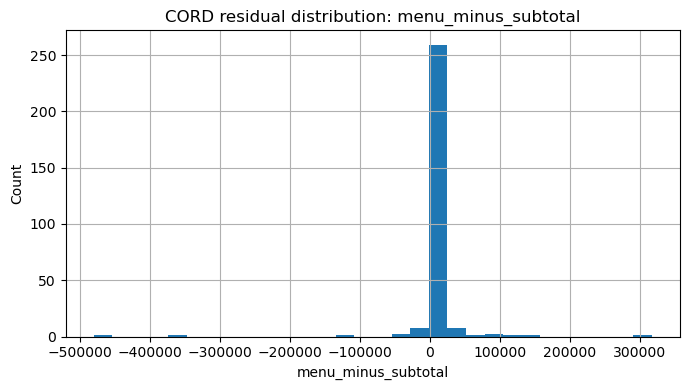

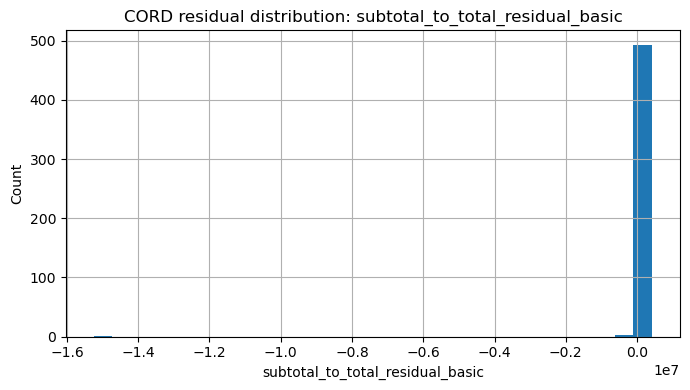

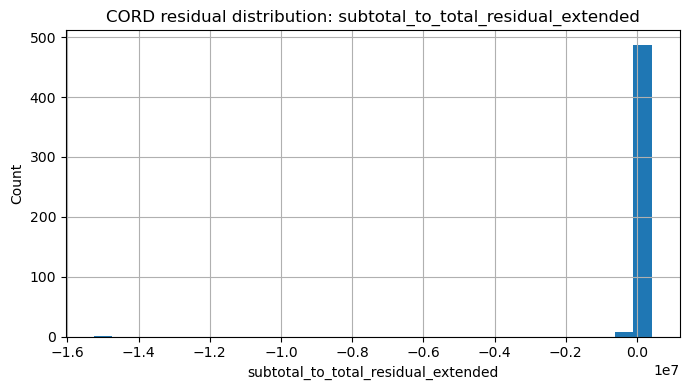

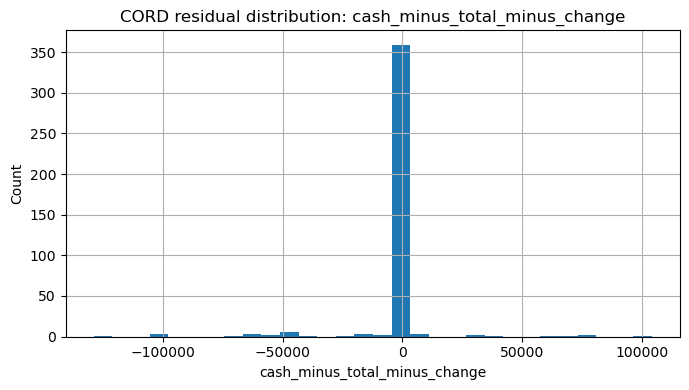

In [ ]:
x